# **XGBoost for PJME Electricity Consumption Data**

### **Learning Resources**
[Getting started with XGBoost](https://www.youtube.com/watch?v=vV12dGe_Fho) by Rob Mulla  
[Advanced Time-series Techniques](https://www.youtube.com/watch?v=z3ZnOW-S550&t=1s) by Rob Mulla  
[TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html) from sklearn docs

### **Learning Points**
* If plot shows weird lines, it is likely because the df index is not sorted. `df = df.sort_index()`
* Calculate and sort descending `error` as a way to quickly see where your model performs poorly or to identify anomalous data points `error = actual - pred`
* Time-series split (Cross-validation) tests whether the model generalises forward in time, which is the actual real-world task. Normal cross-validation is invalid, the model would train on future data to predict the past, breaking temporal dependencies (past values influence today's value)

---

In [135]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_percentage_error

import xgboost as xgb

# global plot style
plt.style.use('fivethirtyeight')
sns.set_theme(
  style='darkgrid',
  palette='muted',
  rc={
    'figure.figsize': (15, 5),
    'axes.titlesize': 20,
    'axes.titleweight': 'bold',
  }
)

---

### Load & Preview Dataset

In [136]:
df = pd.read_csv("data/PJME_hourly.csv")
df = df.set_index('Datetime')
df.index = pd.to_datetime(df.index)
df = df.sort_index()
print(f"No. rows: {df.shape[0]}")
df.head()

No. rows: 145366


,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


## EDA

In [137]:
df.describe(include='all')

,PJME_MW
count,145366.000000
mean,32080.222831
std,6464.012166
min,14544.000000
25%,27573.000000
50%,31421.000000
75%,35650.000000
max,62009.000000


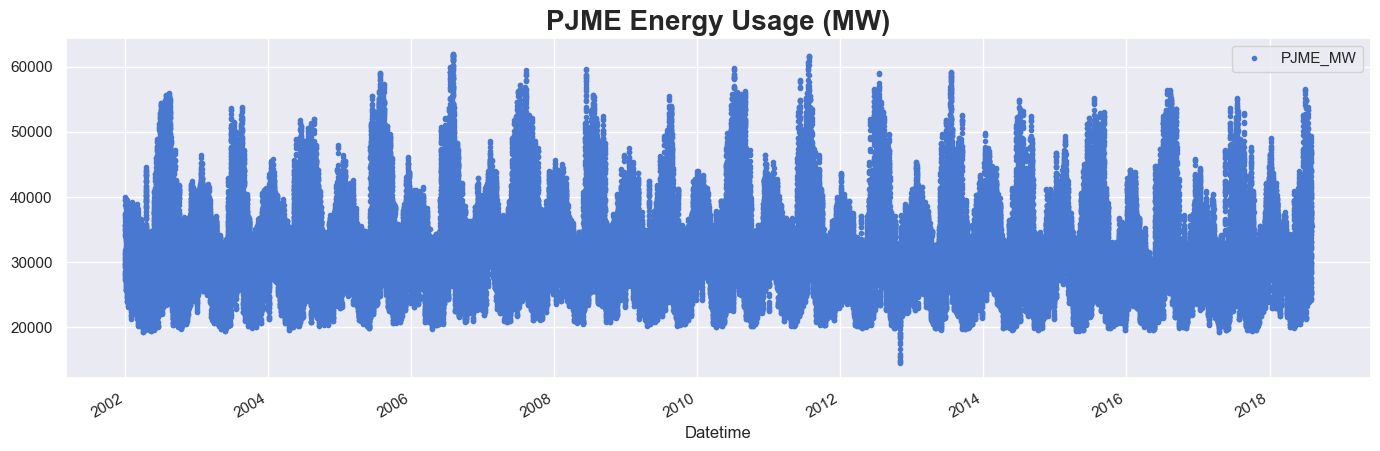

In [138]:
df.plot(
  style='.', 
  title="PJME Energy Usage (MW)"
)
plt.show()

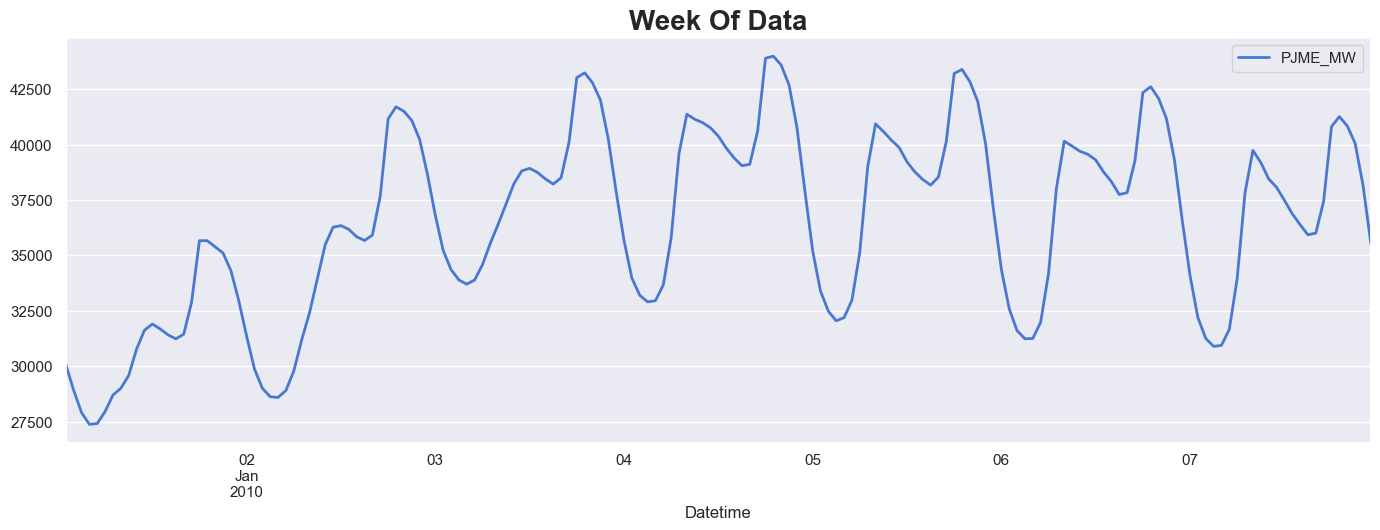

In [139]:
df.loc[(df.index > '2010-01-01') & (df.index < '2010-01-08')] \
  .plot(figsize=(15, 5), title='Week Of Data', linewidth=2)
plt.show()

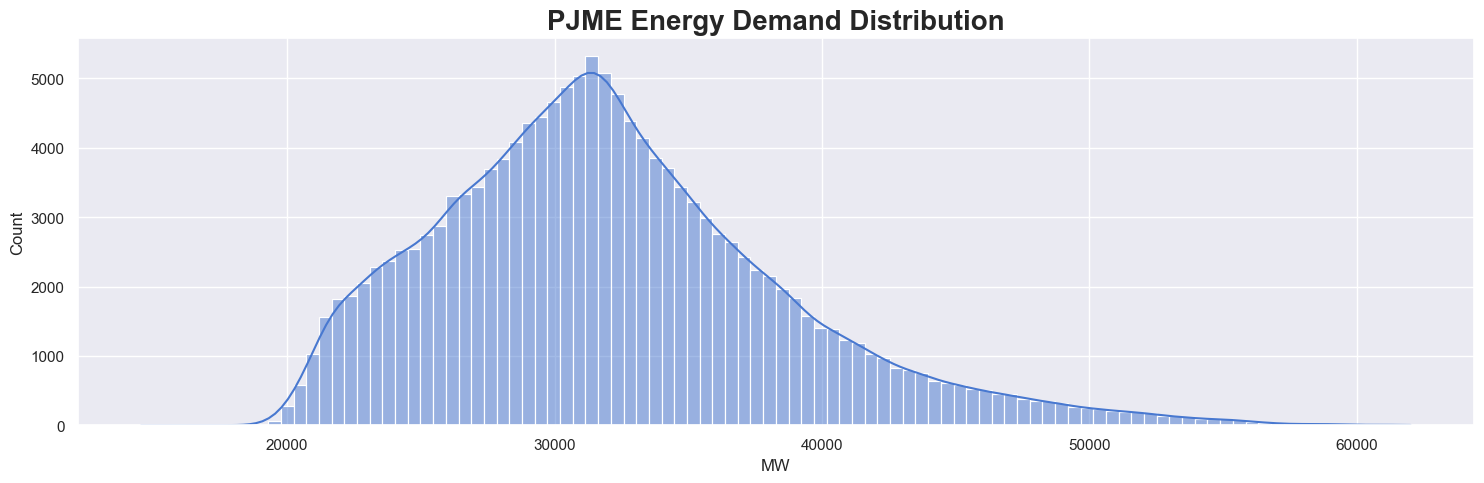

In [140]:
sns.histplot(
  data=df,
  x='PJME_MW',
  bins=100,
  kde=True
)
plt.title('PJME Energy Demand Distribution')
plt.xlabel('MW')
plt.tight_layout()
plt.show()

### Investigate Anomalous Trough around 2013

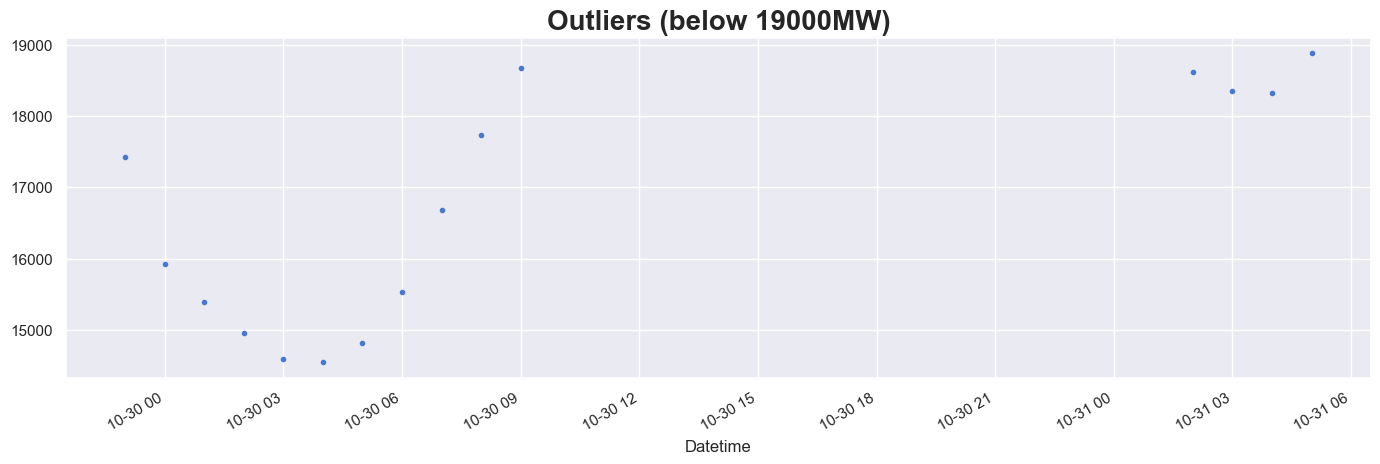

In [141]:
df.loc[(df["PJME_MW"] < 19000), "PJME_MW"].plot(
  style=".",
  title="Outliers (below 19000MW)"
)
plt.show()

In [142]:
# Remove outlier data
df = df.query("PJME_MW > 19000")
df.describe().loc[["min", "max"], "PJME_MW"]

min    19085.0
max    62009.0
Name: PJME_MW, dtype: float64

## Feature Engineering for XGBoost

In [143]:
def create_features(df):
  df = df.copy()
  df['hour']       = df.index.hour
  df['dayofweek']  = df.index.dayofweek
  df['month']      = df.index.month
  df['quarter']    = df.index.quarter
  df['year']       = df.index.year
  df['dayofyear']  = df.index.dayofyear
  df['dayofmonth'] = df.index.day
  df['weekofyear'] = df.index.isocalendar().week.astype(int)
  return df

df = create_features(df)
df.head(1)

,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear
Datetime,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,1,1


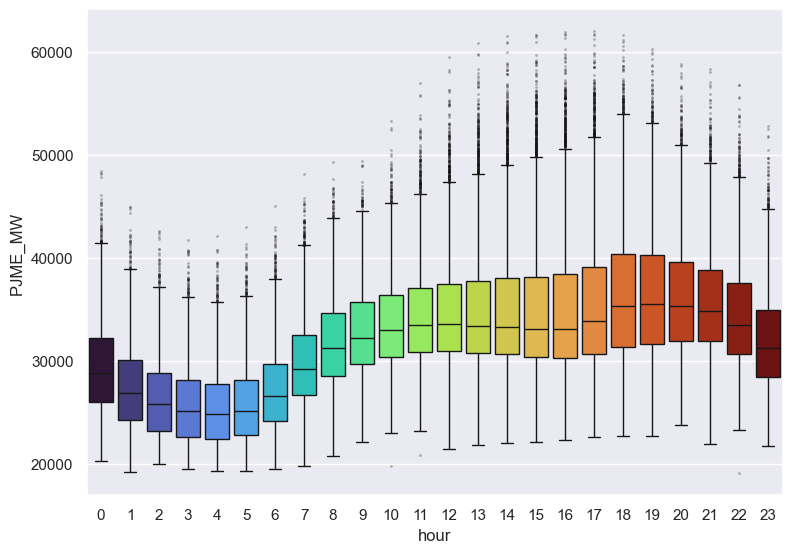

In [144]:
plt.figure(figsize=(8, 6))
sns.boxplot(
  data=df, 
  x='hour', y='PJME_MW',
  palette='turbo', hue="hour", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

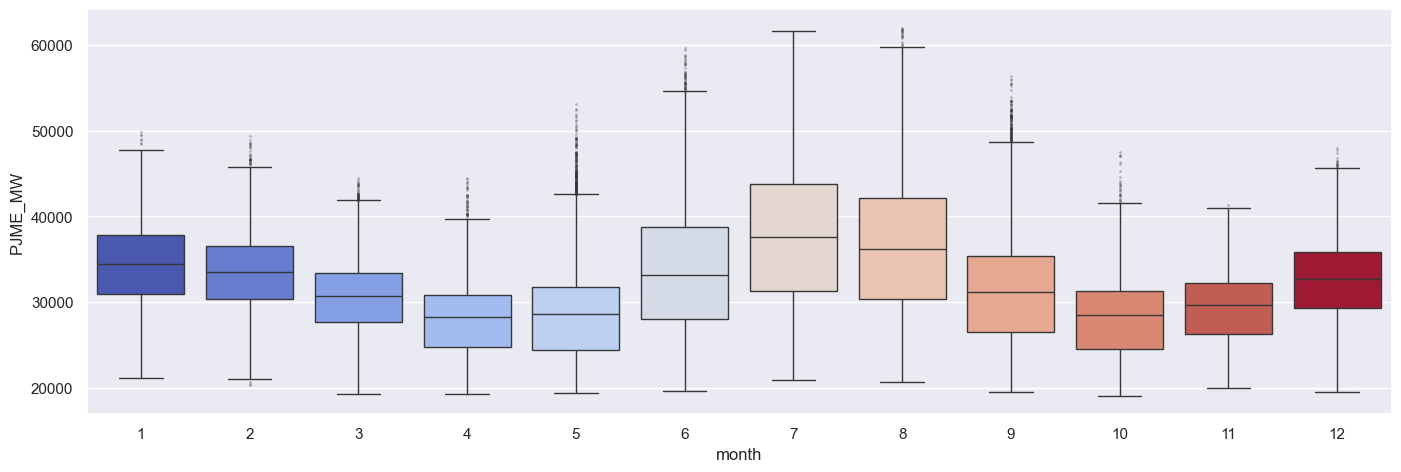

In [145]:
sns.boxplot(
  data=df, 
  x='month', y='PJME_MW',
  palette='coolwarm', hue="month", legend=False,
  flierprops=dict(marker='o', markersize=1, alpha=0.3)
)
plt.show()

## Model Training

In [146]:
tscv = TimeSeriesSplit(
  test_size=24*7*12, 
  gap=24
) # 12 weeks per fold

TARGET = 'PJME_MW'

### v1: Baseline Calendar Features

Fold 0: Train=135247 rows, Test=2016 rows
Fold 1: Train=137263 rows, Test=2016 rows
Fold 2: Train=139279 rows, Test=2016 rows
Fold 3: Train=141295 rows, Test=2016 rows
Fold 4: Train=143311 rows, Test=2016 rows


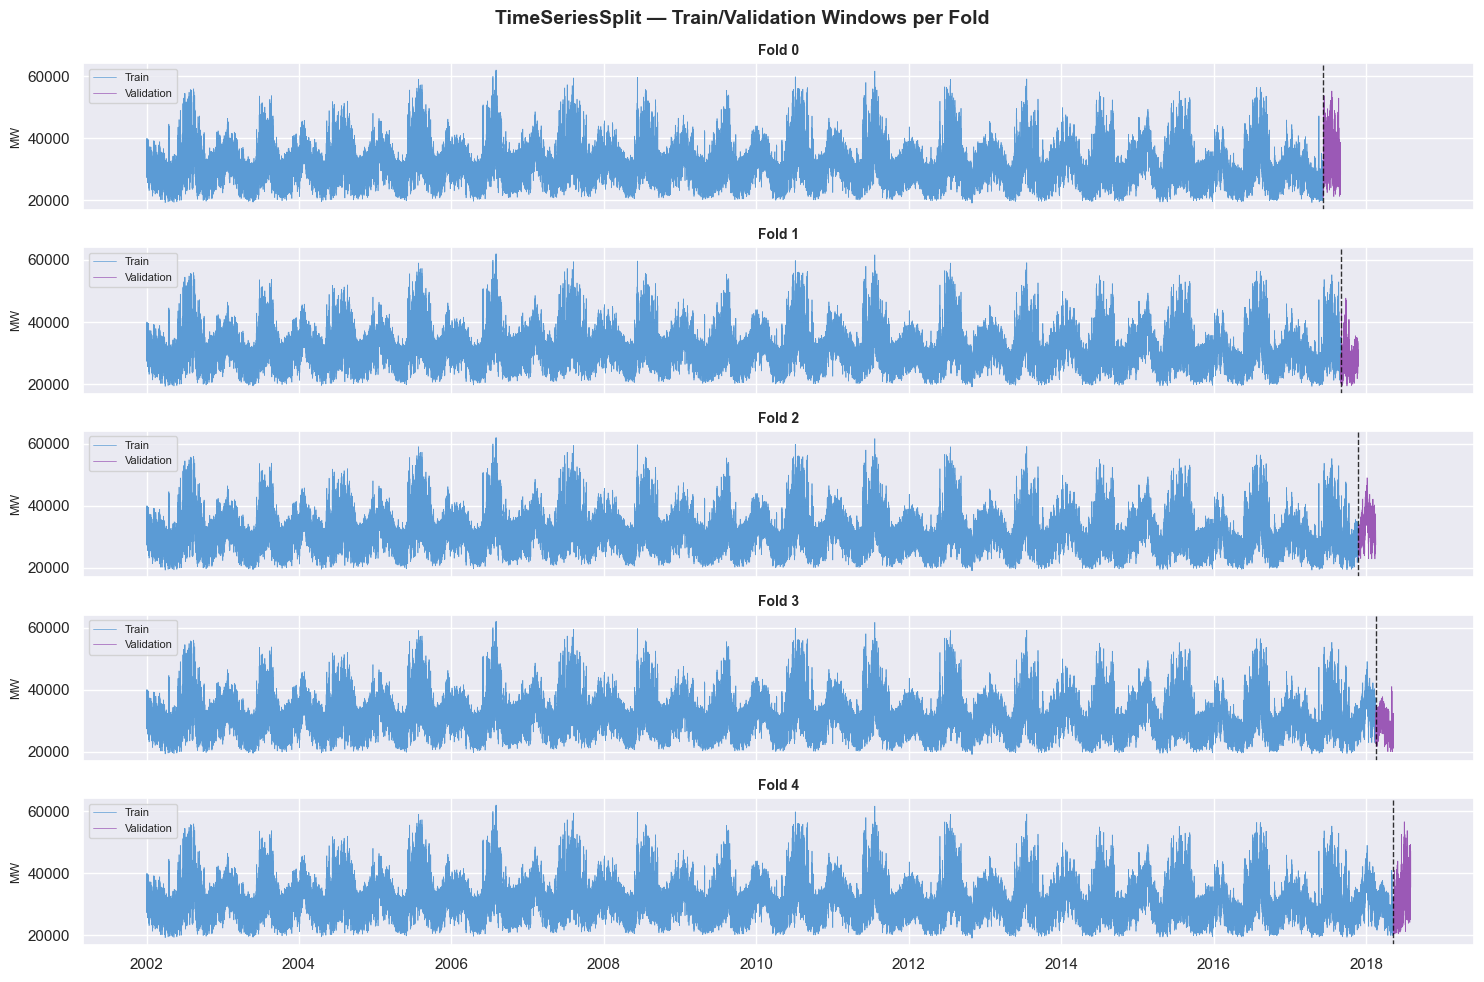

[0]	validation_0-rmse:6436.43743	validation_1-rmse:7766.96083
[100]	validation_0-rmse:4663.65621	validation_1-rmse:5307.99506
[200]	validation_0-rmse:4006.35963	validation_1-rmse:4562.41915
[300]	validation_0-rmse:3639.36650	validation_1-rmse:4457.32028
[364]	validation_0-rmse:3501.66511	validation_1-rmse:4467.05916
Fold 0 RMSE: 4452.3MW
[0]	validation_0-rmse:6457.81319	validation_1-rmse:6081.49692
[100]	validation_0-rmse:4667.15909	validation_1-rmse:4963.08841
[200]	validation_0-rmse:4019.95297	validation_1-rmse:4558.18308
[300]	validation_0-rmse:3656.64192	validation_1-rmse:4225.42829
[400]	validation_0-rmse:3463.70786	validation_1-rmse:4044.39657
[492]	validation_0-rmse:3357.42676	validation_1-rmse:3999.45868
Fold 1 RMSE: 3987.2MW
[0]	validation_0-rmse:6452.42894	validation_1-rmse:5295.87729
[100]	validation_0-rmse:4679.38336	validation_1-rmse:4589.28912
[200]	validation_0-rmse:4028.95400	validation_1-rmse:4446.61908
[300]	validation_0-rmse:3669.81844	validation_1-rmse:4357.55650
[3

In [147]:
FEATURES = [
  'hour', 'dayofweek', 'month', 'quarter', 'year', 'dayofyear', 'dayofmonth', 'weekofyear'
]

# collect data for the 5 regressors across 5 folds for analysis later
fold_scores = []
predictions_raw = pd.DataFrame()
feature_importances = pd.DataFrame(index=FEATURES)

fig, axes = plt.subplots(5, 1, figsize=(15, 10), sharex=True)
fig.suptitle('TimeSeriesSplit — Train/Validation Windows per Fold', fontsize=14, fontweight='bold')

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):
  print(f"Fold {fold}: Train={len(train_idx)} rows, Test={len(test_idx)} rows")

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Plot train/validation split per fold
  ax = axes[fold]
  ax.plot(y_train.index, y_train.values, color='#5B9BD5', linewidth=0.5, label='Train')
  ax.plot(y_test.index,  y_test.values,  color='#9B59B6', linewidth=0.5, label='Validation')
  ax.axvline(y_test.index.min(), color="black", linewidth=1, alpha=0.8, ls="--")
  ax.set_ylabel('MW', fontsize=9)
  ax.set_title(f'Fold {fold}', fontsize=10)
  ax.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df[TARGET])):

  # Slice dataset
  X_train, y_train = df[FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
  X_test,  y_test  = df[FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

  # Train XGB
  reg = xgb.XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01,
    max_depth=3,
    early_stopping_rounds=50, # prevent overfitting by stopping model if validation metric (RMSE) increases above previous rounds
    eval_metric='rmse',
    seed=42
  )
  reg.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=100
  )

  # Predict
  preds = reg.predict(X_test)
  score = np.sqrt(np.mean((preds - y_test)**2)) # RMSE in MW
  fold_scores.append(score)
  print(f"Fold {fold} RMSE: {score:.1f}MW")

  # Save data (feat importances, predictions)
  fold_preds = pd.DataFrame({
    'actual':   y_test.values,
    'predicted': preds,
    'fold':      fold
  }, index=y_test.index)
  predictions_raw = pd.concat([predictions_raw, fold_preds])
  feature_importances[f'fold_{fold}'] = reg.feature_importances_

print(f"\nMean RMSE: {np.mean(fold_scores):.1f} ± {np.std(fold_scores):.1f} MW")

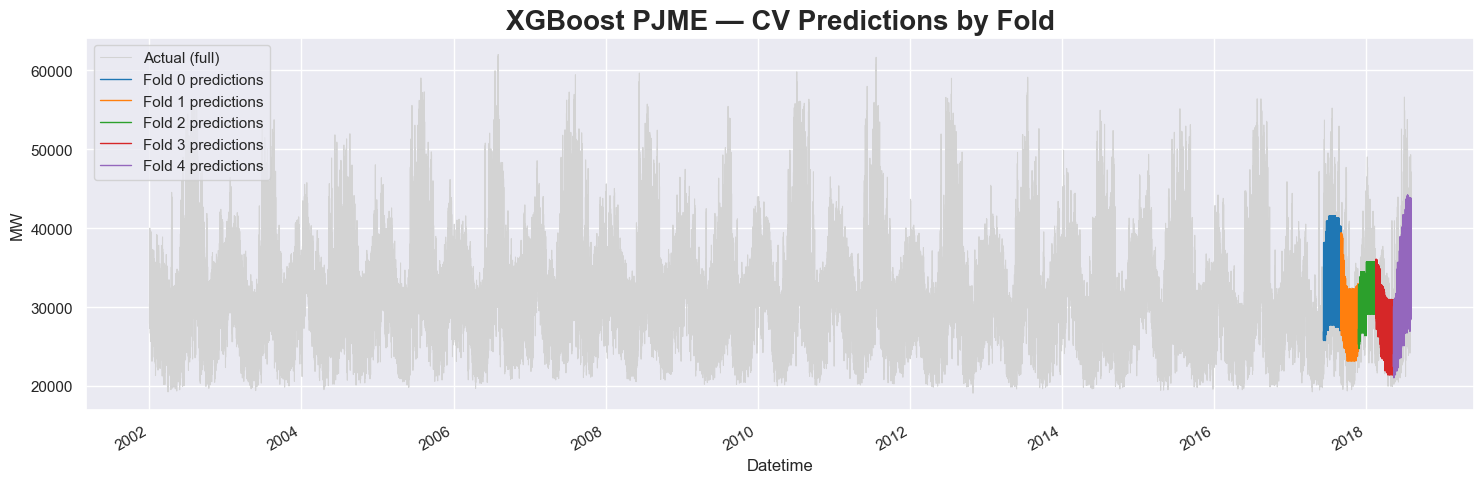

In [148]:
fig, ax = plt.subplots(figsize=(15, 5))

# Full actual series in the background
df[TARGET].plot(ax=ax, color='lightgray', label='Actual (full)', linewidth=0.75)

# Overlay each fold's predictions in a distinct color
colors = plt.cm.tab10.colors
for fold in predictions_raw['fold'].unique():
  mask = predictions_raw['fold'] == fold
  predictions_raw.loc[mask, 'predicted'].plot(
    ax=ax, color=colors[fold], label=f'Fold {fold} predictions', linewidth=1
  )

ax.set_title('XGBoost PJME — CV Predictions by Fold')
ax.set_xlabel('Datetime')
ax.set_ylabel('MW')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

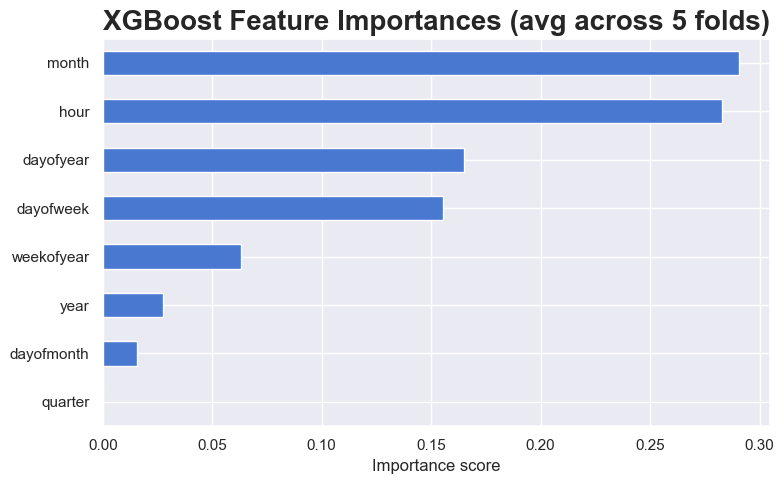

In [149]:
# avg across folds and sort
feature_importances['mean'] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values('mean', ascending=True)

feature_importances['mean'].plot(
  kind='barh',
  figsize=(8, 5),
  title='XGBoost Feature Importances (avg across 5 folds)'
)
plt.xlabel('Importance score')
plt.tight_layout()
plt.show()

Features like month and dayofyear are highly correlated. Removing month may cause the importance of dayofyear to spike. The raw feature importances are not always the most reliable metric to evaluate each individual feature, moreso how they all work together.

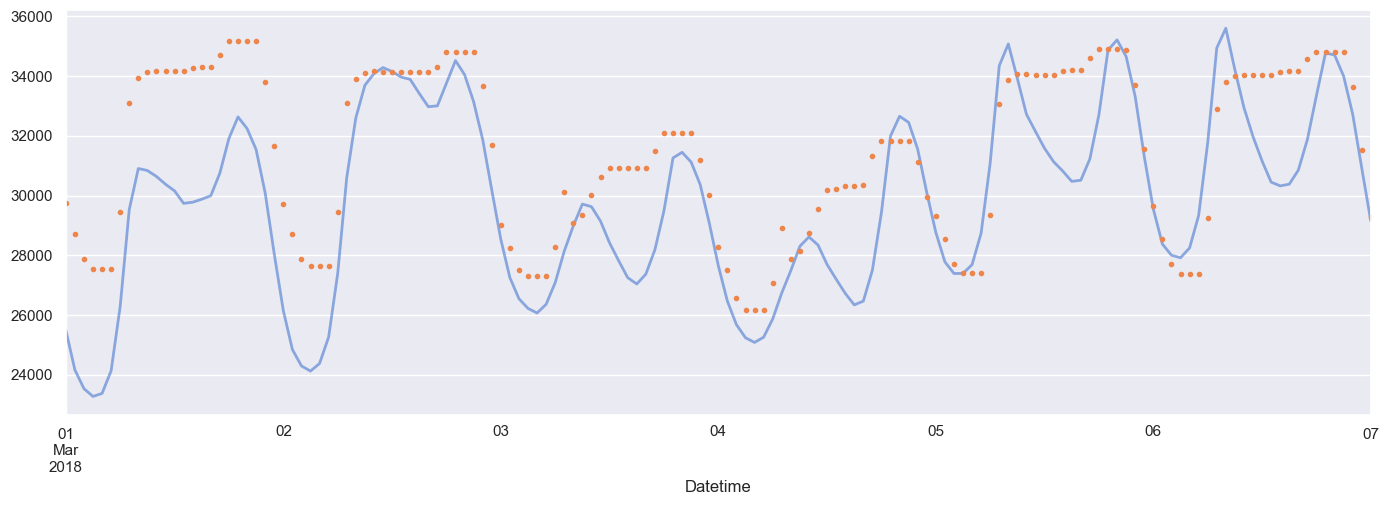

In [150]:
YEAR = 2018
MONTH = 3

mask = (predictions_raw.index >= f'{YEAR}-{MONTH}-01') & (predictions_raw.index <= f'{YEAR}-{MONTH}-07')
predictions_raw.loc[mask, "actual"].plot(linewidth=2, alpha=0.6)
predictions_raw.loc[mask, "predicted"].plot(
  style=".",
  linewidth=3
)
plt.show()

### v2-v6: Experiment New Features

In [151]:
from pandas.tseries.holiday import USFederalHolidayCalendar

def add_annual_lags(df):
  df = df.copy()
  target_map = df["PJME_MW"].to_dict()
  df["lag1"] = (df.index - pd.Timedelta('364 days')).map(target_map)
  df["lag2"] = (df.index - pd.Timedelta('728 days')).map(target_map)
  df["lag3"] = (df.index - pd.Timedelta('1092 days')).map(target_map)
  return df

def add_short_lags(df):
  df = df.copy()
  df['lag_24h']  = df['PJME_MW'].shift(24)
  df['lag_48h']  = df['PJME_MW'].shift(48)
  df['lag_168h'] = df['PJME_MW'].shift(168)
  return df

def add_rolling(df):
  df = df.copy()
  df['rolling_mean_24h']  = df['PJME_MW'].shift(1).rolling(24).mean()
  df['rolling_mean_168h'] = df['PJME_MW'].shift(1).rolling(168).mean()
  return df

def add_holidays(df):
  df = df.copy()
  cal      = USFederalHolidayCalendar()
  holidays = cal.holidays(start=df.index.min(), end=df.index.max())
  df['is_holiday'] = df.index.normalize().isin(holidays).astype(int)
  return df

df = add_annual_lags(df)
df = add_short_lags(df)
df = add_rolling(df)
df = add_holidays(df)
df['is_weekend']   = (df.index.dayofweek >= 5).astype(int)
df['is_peak_hour'] = df.index.hour.isin(range(8, 21)).astype(int)
df = df.dropna()

print(f"No. rows after cleaning: {df.shape[0]}")
df.head(1)

No. rows after cleaning: 119079


,PJME_MW,hour,dayofweek,month,quarter,year,dayofyear,dayofmonth,weekofyear,lag1,lag2,lag3,lag_24h,lag_48h,lag_168h,rolling_mean_24h,rolling_mean_168h,is_holiday,is_weekend,is_peak_hour
Datetime,,,,,,,,,,,,,,,,,,,,
2004-12-28 01:00:00,33781.0,1,1,12,4,2004,363,28,53,26506.0,26498.0,30393.0,30452.0,30615.0,35744.0,36852.708333,34119.214286,0,0,0


In [152]:
def run_experiment(df, label, features, params, tscv, target=TARGET):
  fold_scores = {"rmse": [], "mape": []}
  predictions = pd.DataFrame()
  feature_importances = pd.DataFrame(index=features)

  for fold, (train_idx, test_idx) in enumerate(tscv.split(df[target])):
    X_train, y_train = df[features].iloc[train_idx], df[target].iloc[train_idx]
    X_test,  y_test  = df[features].iloc[test_idx],  df[target].iloc[test_idx]

    reg = xgb.XGBRegressor(**params)
    reg.fit(
      X_train, y_train,
      eval_set=[(X_train, y_train), (X_test, y_test)],
      verbose=False
    )

    num_trees = reg.best_iteration
    preds = reg.predict(X_test)
    rmse = np.sqrt(np.mean((preds - y_test) ** 2))
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    fold_scores["rmse"].append(rmse)
    fold_scores["mape"].append(mape)

    fold_preds = pd.DataFrame({
      'actual':    y_test.values,
      'predicted': preds,
      'fold':      fold
    }, index=y_test.index)
    predictions = pd.concat([predictions, fold_preds])
    feature_importances[f'fold_{fold}'] = reg.feature_importances_

  feature_importances['mean'] = feature_importances.mean(axis=1)
  mean_rmse = np.mean(fold_scores["rmse"])
  mean_mape = np.mean(fold_scores["mape"])
  print(f"{label} ({num_trees} trees)\n\tMean RMSE: {mean_rmse:.1f} ± {np.std(fold_scores["rmse"]):.1f} MW\n\tMean MAPE: {mean_mape:.1f}%")

  return {
    'label':               label,
    'predictions':         predictions,
    'feature_importances': feature_importances['mean'].sort_values(ascending=True),
    'fold_scores':         fold_scores,
    'mean_rmse':           mean_rmse,
    'mean_mape':           mean_mape,
  }


def plot_comparison(results, year=2018, month=2):
  START = f'{year}-{month:02d}-01'
  END   = f'{year}-{month:02d}-08'
  n     = len(results)

  fig, axes = plt.subplots(n, 2, figsize=(18, 5 * n))
  fig.suptitle('Model Comparison', fontsize=28, fontweight='bold', y=1.01)

  for i, r in enumerate(results):
    preds = r['predictions']
    fi    = r['feature_importances']
    mask  = (preds.index >= START) & (preds.index <= END)
    week  = preds.loc[mask]

    rmse = np.sqrt(np.mean((week['predicted'] - week['actual']) ** 2))
    mape = mean_absolute_percentage_error(week['actual'], week['predicted']) * 100

    # Feature importances
    ax_fi = axes[i, 0]
    fi.plot(kind='barh', ax=ax_fi)
    ax_fi.set_title(r['label'], fontweight='bold')
    ax_fi.set_xlabel('Importance score')

    # Actual vs predicted
    ax_pred = axes[i, 1]
    ax_pred.plot(week.index, week['actual'],    label='Actual',    linewidth=2)
    ax_pred.plot(week.index, week['predicted'], label='Predicted', linewidth=1.5, linestyle='dotted')
    ax_pred.set_title(f'Feb {month:02d} – Feb 08\nRMSE={rmse:.1f} MW  MAPE={mape:.2f}%', fontsize=11)
    ax_pred.set_xlabel('Datetime')
    ax_pred.set_ylabel('MW')
    ax_pred.legend()
    ax_pred.tick_params(axis='x', rotation=30)

  plt.tight_layout()
  plt.show()

V1 — Baseline (498 trees)
	Mean RMSE: 3831.9 ± 674.1 MW
	Mean MAPE: 9.0%
V2 — V1 + Annual Lag features (409 trees)
	Mean RMSE: 3855.0 ± 803.8 MW
	Mean MAPE: 9.0%
V3 — V2 + Rolling features (1997 trees)
	Mean RMSE: 1883.0 ± 270.6 MW
	Mean MAPE: 4.3%
V4 — V3 + Short-term Lags (1999 trees)
	Mean RMSE: 1890.4 ± 325.5 MW
	Mean MAPE: 4.4%
V5 — V4 + Holiday, weekend, peak hour features (1999 trees)
	Mean RMSE: 1890.3 ± 315.9 MW
	Mean MAPE: 4.4%


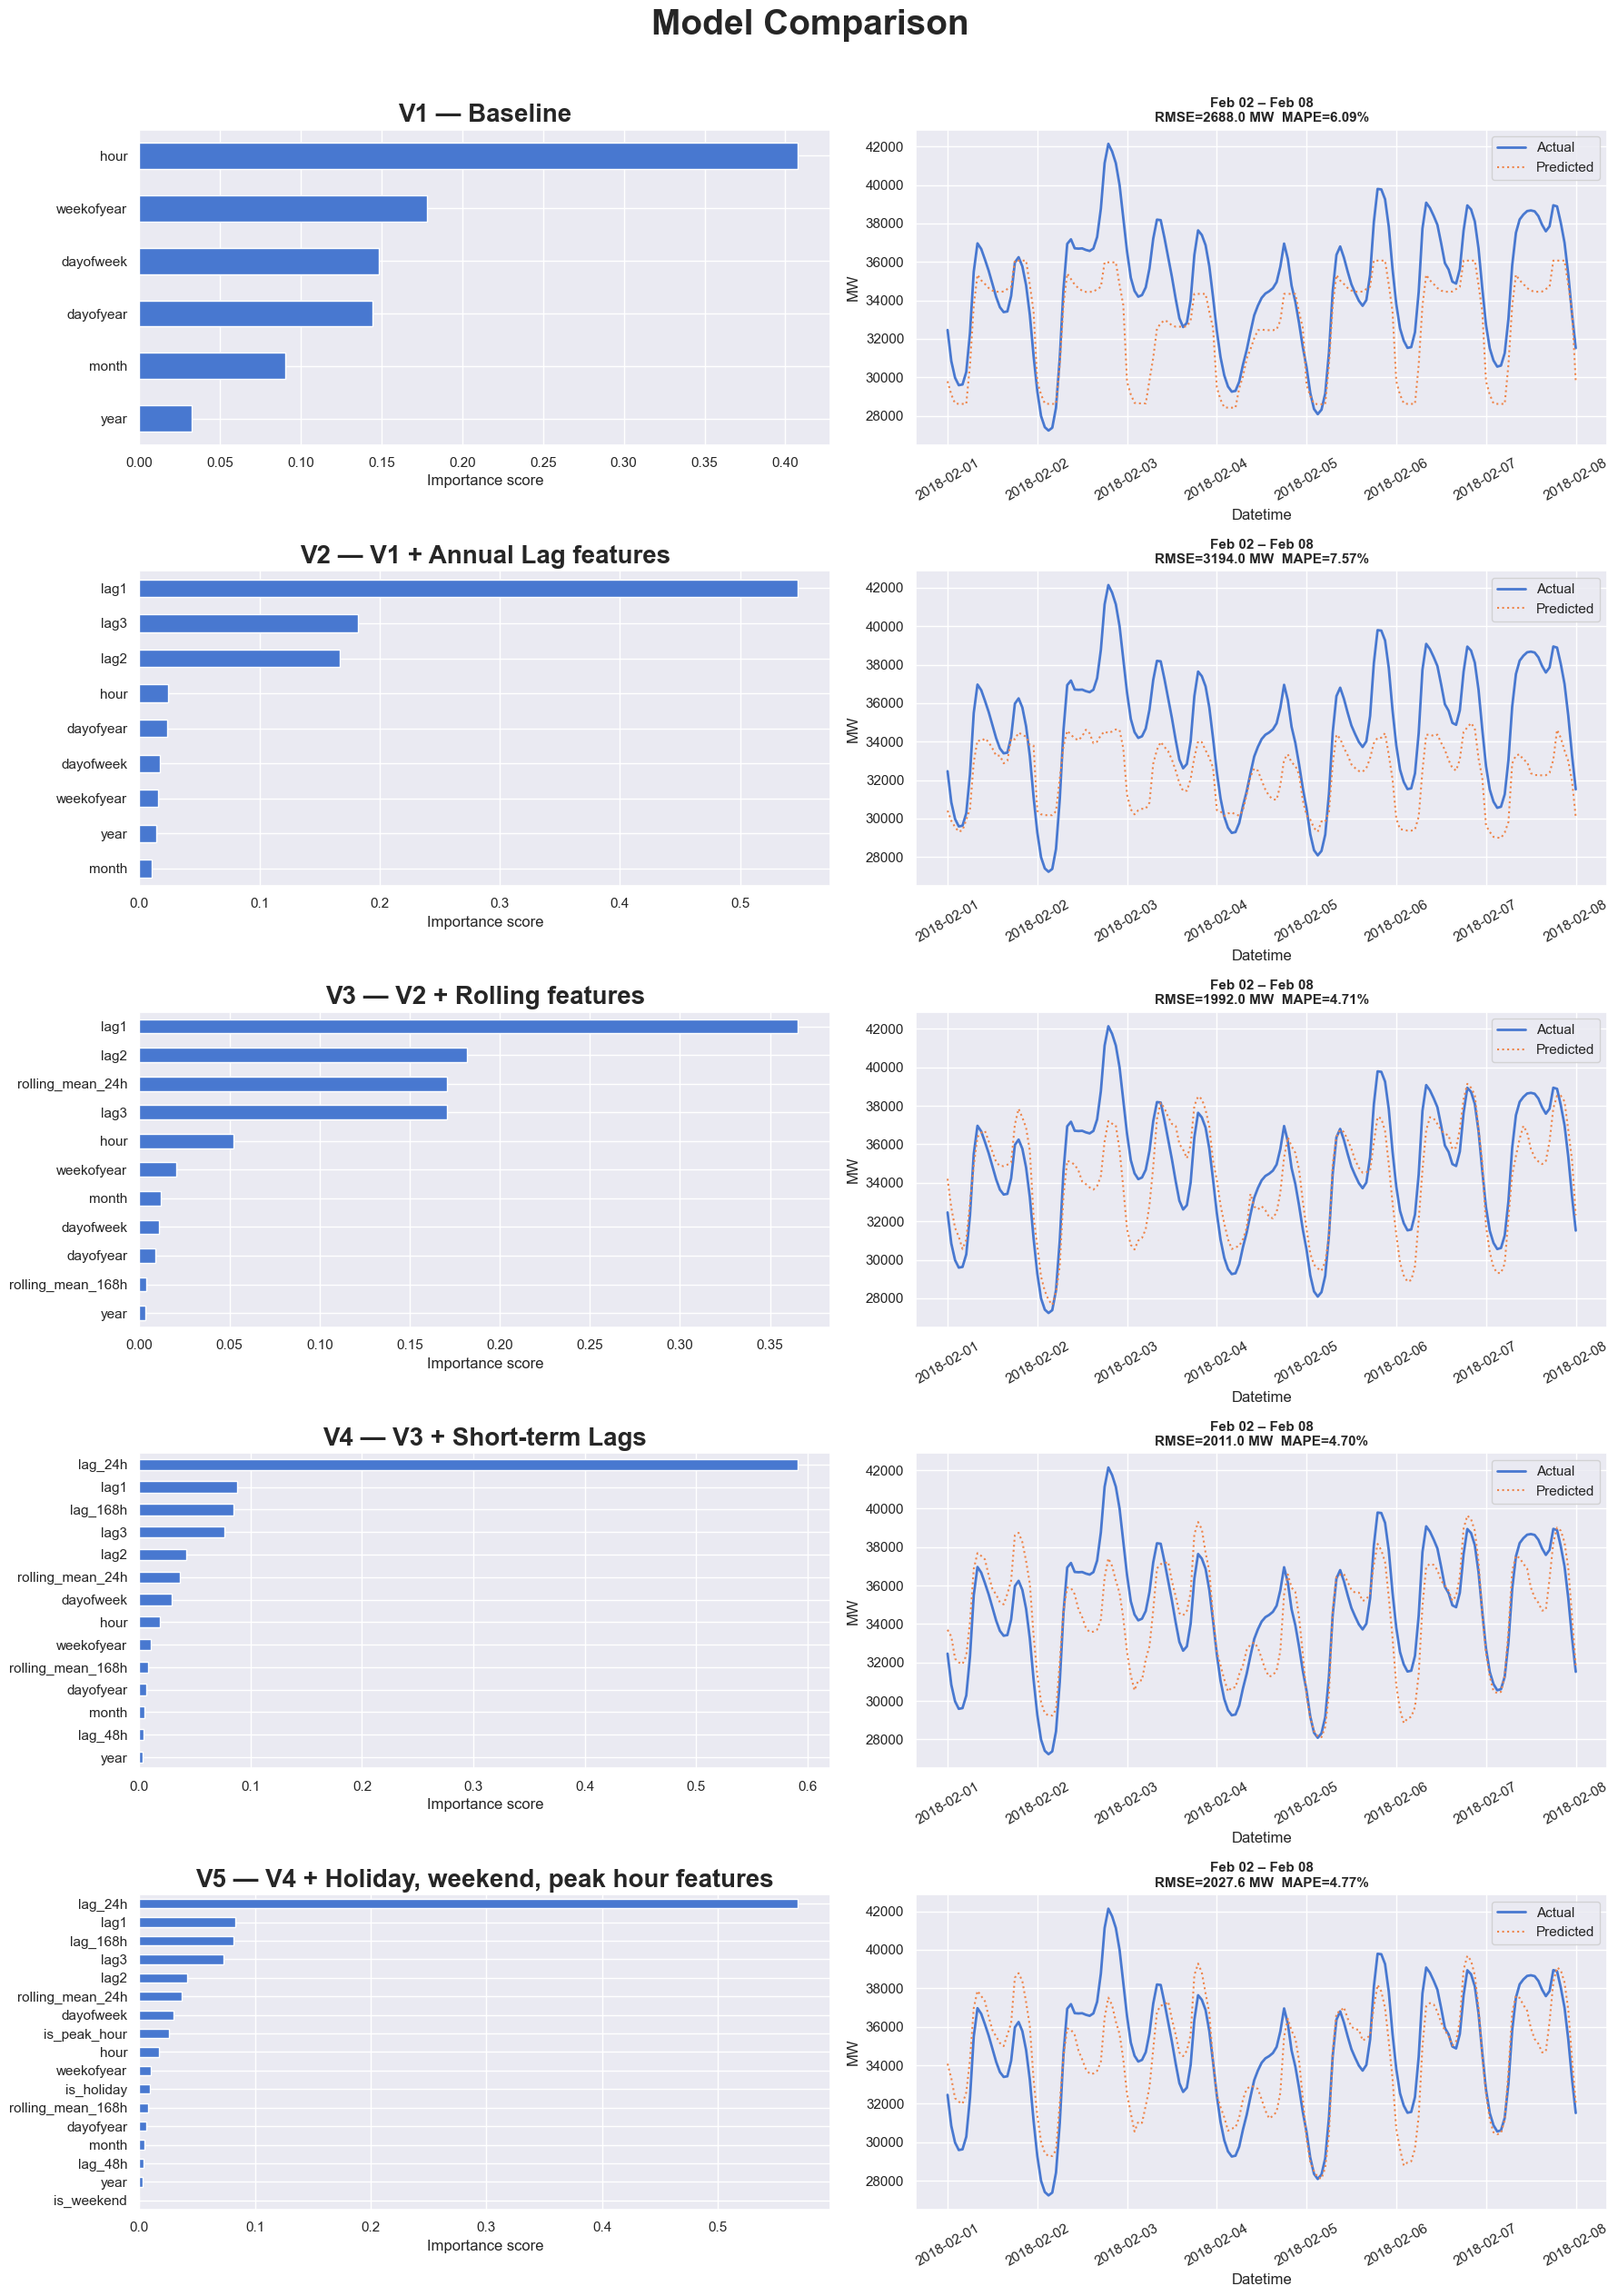

In [153]:
# Experiment configs
BASE_PARAMS = dict(
  learning_rate=0.01,
  early_stopping_rounds=50,
  eval_metric='rmse',
  seed=42
)

experiments = [
  {
    'label':    'V1 — Baseline',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
  {
    'label':    'V2 — V1 + Annual Lag features',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                  'lag1', 'lag2', 'lag3'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
  {
    'label':    'V3 — V2 + Rolling features',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                  'lag1', 'lag2', 'lag3', 'rolling_mean_24h', 'rolling_mean_168h'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
  {
    'label':    'V4 — V3 + Short-term Lags',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                  'lag1', 'lag2', 'lag3', 'lag_24h', 'lag_48h', 'lag_168h', 
                  'rolling_mean_24h', 'rolling_mean_168h'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
  {
    'label':    'V5 — V4 + Holiday, weekend, peak hour features',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
                  'lag1', 'lag2', 'lag3', 'lag_24h', 'lag_48h', 'lag_168h',
                  'rolling_mean_24h', 'rolling_mean_168h',
                  'is_holiday', 'is_weekend', 'is_peak_hour'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
]

# Run
tscv = TimeSeriesSplit(test_size=24*7*12, gap=24)
results = [run_experiment(df, exp['label'], exp['features'], exp['params'], tscv) for exp in experiments]
plot_comparison(results)

Feature interference occurs, since lag_24h and rolling_mean_24h are highly correlated. XGBoost's tree splits gets confused by these two features, causing it to use the strongest feature rolling_mean_XXh less. Thus you see the increase in RMSE and spike in feature importance for lag_24h.

V3 is clearly the most optimal model, rolling_mean_24h is the strongest feature.

V1 — Baseline (498 trees)
	Mean RMSE: 3831.9 ± 674.1 MW
	Mean MAPE: 9.0%
V6 — Annual Lag + Rolling + Holiday (1998 trees)
	Mean RMSE: 1885.3 ± 261.3 MW
	Mean MAPE: 4.4%


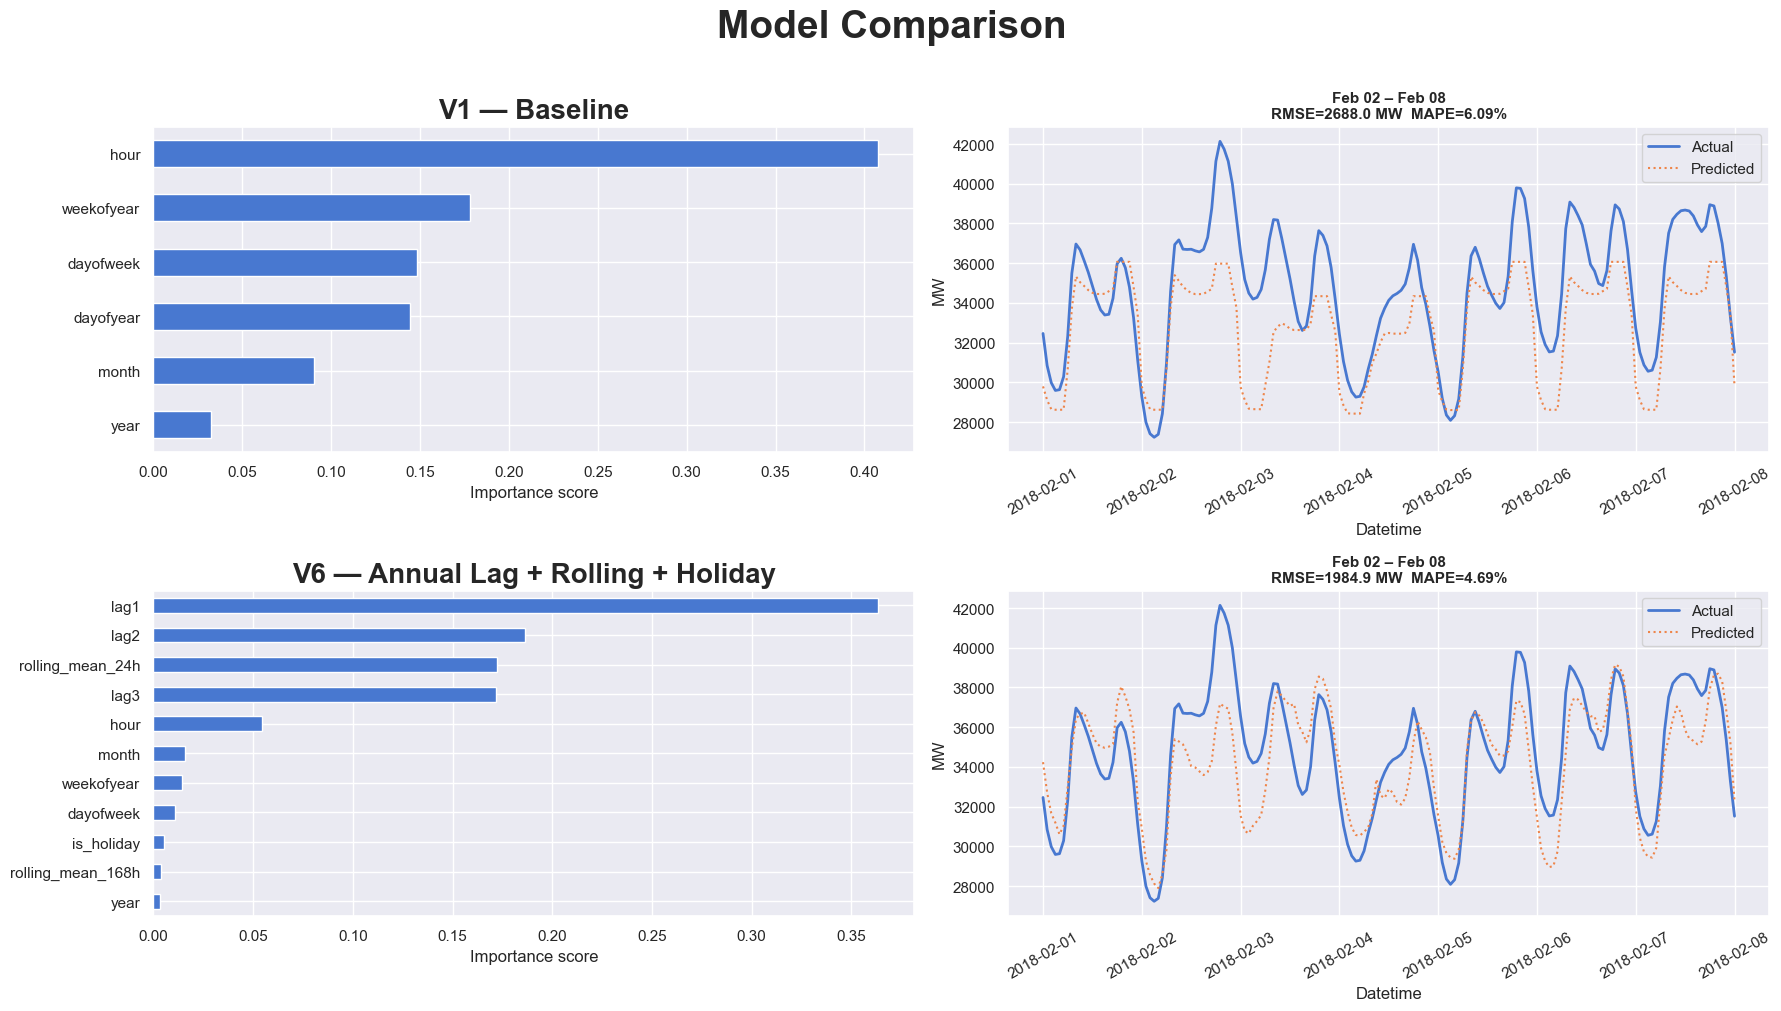

In [154]:
experiments = [
  {
    'label':    'V1 — Baseline',
    'features': ['hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
  {
    'label':    'V6 — Annual Lag + Rolling + Holiday',
    'features': ['hour', 'dayofweek', 'month', 'year', 'weekofyear', # remove dayofyear as its signal is captured by month. keep year for long-term demand trend
                  'lag1', 'lag2', 'lag3', 'rolling_mean_24h', 'rolling_mean_168h',
                  'is_holiday'],
    'params':   {**BASE_PARAMS, 'n_estimators': 2000, 'max_depth': 5},
  },
]

# Run
tscv = TimeSeriesSplit(test_size=24*7*12, gap=24)
results = [run_experiment(df, exp['label'], exp['features'], exp['params'], tscv) for exp in experiments]
plot_comparison(results)

I believe the model has reached its limit with pure feature engineering, with the exception of adding the exogeneous variables such as hourly Temperature. I will try Hyperparameter tuning now, which I'd expect to yield a significant decrease in RMSE and MAPE on V6. 

## Hyperparameter Tuning

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)  # suppress per-trial logs

V6_FEATURES = [
  'hour', 'dayofweek', 'month', 'year', 'dayofyear', 'weekofyear',
  'lag1', 'lag2', 'lag3', 'rolling_mean_24h', 'rolling_mean_168h',
  'is_holiday'
]

def objective(trial):
  params = {
    'n_estimators':      2000,
    'learning_rate':     trial.suggest_float('learning_rate',    0.005, 0.05,  log=True),
    'max_depth':         trial.suggest_int(  'max_depth',        3,     8),
    'subsample':         trial.suggest_float('subsample',        0.6,   1.0),
    'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6,   1.0),
    'min_child_weight':  trial.suggest_int(  'min_child_weight', 1,     10),
    'reg_alpha':         trial.suggest_float('reg_alpha',        0,     1.0),
    'reg_lambda':        trial.suggest_float('reg_lambda',       1.0,   5.0),
    'early_stopping_rounds': 50,
    'eval_metric': 'rmse',
    'seed': 42,
  }

  tscv = TimeSeriesSplit(test_size=24*7*12, gap=24)
  fold_scores = []

  for train_idx, test_idx in tscv.split(df[TARGET]):
    X_train, y_train = df[V6_FEATURES].iloc[train_idx], df[TARGET].iloc[train_idx]
    X_test,  y_test  = df[V6_FEATURES].iloc[test_idx],  df[TARGET].iloc[test_idx]

    reg = xgb.XGBRegressor(**params)
    reg.fit(
      X_train, y_train,
      eval_set=[(X_train, y_train), (X_test, y_test)],
      verbose=False
    )

    preds = reg.predict(X_test)
    fold_scores.append(np.sqrt(np.mean((preds - y_test) ** 2)))

  return np.mean(fold_scores)


# Run
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=50, show_progress_bar=True)

# Results
# print(f"Best RMSE:   {study.best_value:.1f} MW")
# print(f"Best params: {study.best_params}")

Best trial: 23. Best value: 1799.54: 100%|██████████| 50/50 [07:28<00:00,  8.97s/it]Best RMSE:   1799.5 MW

Best params: {'learning_rate': 0.02916132051808668, 'max_depth': 8, 'subsample': 0.7151409968166413, 'colsample_bytree': 0.8391601363940169, 'min_child_weight': 9, 'reg_alpha': 0.6354501197034904, 'reg_lambda': 2.1318080430649533}

V7 — Optuna Tuned (505 trees)
	Mean RMSE: 1789.8 ± 280.4 MW
	Mean MAPE: 4.1%


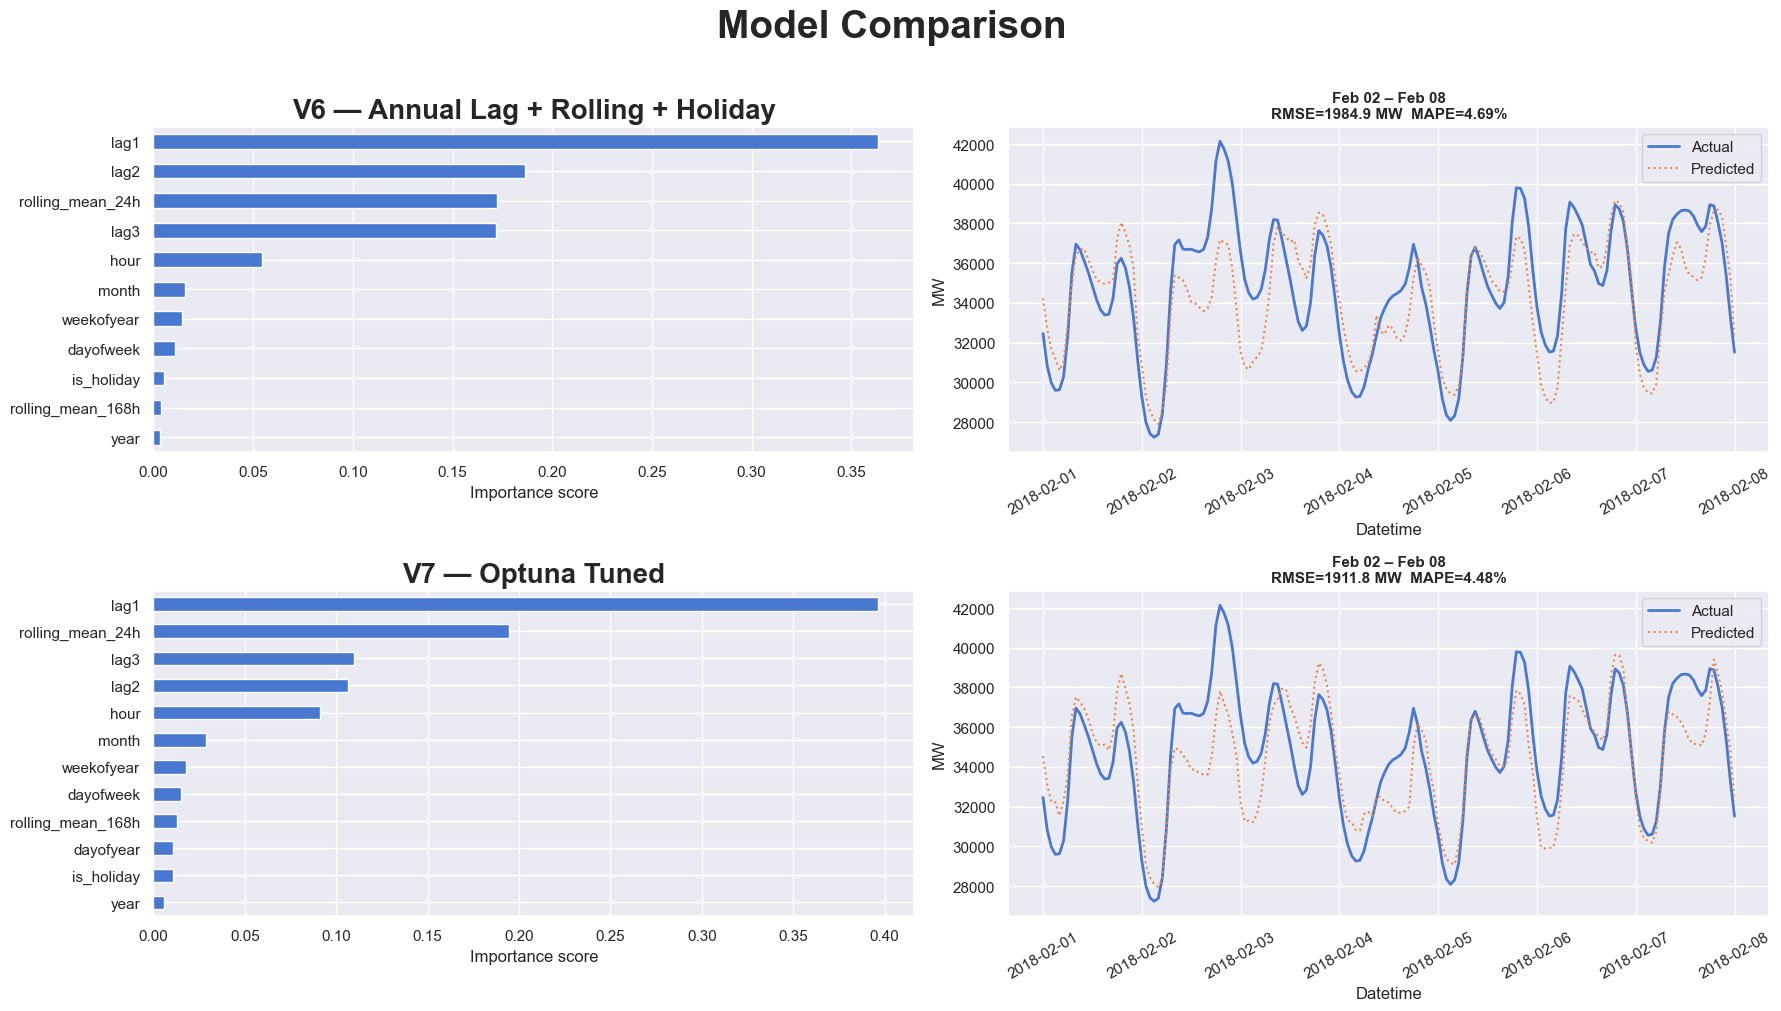

In [ ]:

best_params = {
  # **study.best_params :
  'learning_rate': 0.02916132051808668, 'max_depth': 8, 'subsample': 0.7151409968166413, 'colsample_bytree': 0.8391601363940169, 'min_child_weight': 9, 'reg_alpha': 0.6354501197034904, 'reg_lambda': 2.1318080430649533,

  'n_estimators': 2000,
  'early_stopping_rounds': 50,
  'eval_metric':  'rmse',
  'seed': 42,
}

result_tuned = run_experiment(df, 'V7 — Optuna Tuned', V6_FEATURES, best_params, tscv)
plot_comparison([results[1], result_tuned])  # assuming results[1] is V6

### Retrain V7 on all data

In [157]:
# Train on full dataset with best params
best_params = {
  'n_estimators':          2000,
  'learning_rate':         0.02916132051808668,
  'max_depth':             8,
  'subsample':             0.7151409968166413,
  'colsample_bytree':      0.8391601363940169,
  'min_child_weight':      9,
  'reg_alpha':             0.6354501197034904,
  'reg_lambda':            2.1318080430649533,
  'early_stopping_rounds': 50,
  'eval_metric':           'rmse',
  'seed':                  42,
}

final_model = xgb.XGBRegressor(**best_params)
final_model.fit(
  df[V6_FEATURES], df[TARGET],
  eval_set=[(df[V6_FEATURES], df[TARGET])],
  verbose=100
)

# Save
final_model.save_model('v7_xgboost_pjme.json')

print("Model saved.")

[0]	validation_0-rmse:6338.79213
[100]	validation_0-rmse:1561.24129
[200]	validation_0-rmse:1277.25294
[300]	validation_0-rmse:1167.14831
[400]	validation_0-rmse:1086.77123
[500]	validation_0-rmse:1019.78191
[600]	validation_0-rmse:960.69311
[700]	validation_0-rmse:909.99799
[800]	validation_0-rmse:861.54682
[900]	validation_0-rmse:818.96240
[1000]	validation_0-rmse:782.48107
[1100]	validation_0-rmse:750.30437
[1200]	validation_0-rmse:720.15864
[1300]	validation_0-rmse:691.05621
[1400]	validation_0-rmse:664.18244
[1500]	validation_0-rmse:641.24442
[1600]	validation_0-rmse:618.11402
[1700]	validation_0-rmse:597.52549
[1800]	validation_0-rmse:576.71561
[1900]	validation_0-rmse:558.55189
[1999]	validation_0-rmse:540.35314
Model saved.
